Project Overview

Objective: analyse movement complexity in global flight routes
Approach: data cleaning, behavioural analysis, anomaly detection
Outcome: baseline behaviour established and rare route patterns identified

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
df = pd.read_csv("routes.csv")
df.head()

,airline,airline ID,source airport,source airport id,destination apirport,destination airport id,codeshare,stops,equipment
0,2B,410,AER,2965,KZN,2990,NaN,0,CR2
1,2B,410,ASF,2966,KZN,2990,NaN,0,CR2
2,2B,410,ASF,2966,MRV,2962,NaN,0,CR2
3,2B,410,CEK,2968,KZN,2990,NaN,0,CR2
4,2B,410,CEK,2968,OVB,4078,NaN,0,CR2


In [19]:
df.info()
df.describe()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 67663 entries, 0 to 67662
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   airline                  67663 non-null  str  
 1   airline ID               67663 non-null  str  
 2    source airport          67663 non-null  str  
 3    source airport id       67663 non-null  str  
 4    destination apirport    67663 non-null  str  
 5    destination airport id  67663 non-null  str  
 6    codeshare               14597 non-null  str  
 7    stops                   67663 non-null  int64
 8    equipment               67645 non-null  str  
dtypes: int64(1), str(8)
memory usage: 4.6 MB


airline                        0
airline ID                     0
 source airport                0
 source airport id             0
 destination apirport          0
 destination airport id        0
 codeshare                 53066
 stops                         0
 equipment                    18
dtype: int64

In [20]:
# Remove duplicates
df = df.drop_duplicates()

In [21]:
# ensure stops is numeric
df['stops'] = pd.to_numeric(df['stops'], errors='coerce')

KeyError: 'stops'

In [22]:
# check columns names
df.columns

Index(['airline', 'airline ID', ' source airport', ' source airport id',
       ' destination apirport', ' destination airport id', ' codeshare',
       ' stops', ' equipment'],
      dtype='str')

In [23]:
# strip spacing front/end and bring column names to lower case
df.columns = df.columns.str.strip().str.lower()
df.columns

Index(['airline', 'airline id', 'source airport', 'source airport id',
       'destination apirport', 'destination airport id', 'codeshare', 'stops',
       'equipment'],
      dtype='str')

In [24]:
# rename column
df = df.rename(columns={'destination apirport': 'destination airport'})
df.columns

Index(['airline', 'airline id', 'source airport', 'source airport id',
       'destination airport', 'destination airport id', 'codeshare', 'stops',
       'equipment'],
      dtype='str')

In [25]:
# route identifier
df['route'] = df['source airport'] + "-" + df['destination airport']
df['route'].head()

0    AER-KZN
1    ASF-KZN
2    ASF-MRV
3    CEK-KZN
4    CEK-OVB
Name: route, dtype: str

In [26]:
# most common routes
top_routes = df['route'].value_counts().head(20)
print(top_routes)

route
ORD-ATL    20
ATL-ORD    19
HKT-BKK    13
ORD-MSY    13
ATL-MIA    12
AUH-MCT    12
DOH-BAH    12
JFK-LHR    12
LHR-JFK    12
MIA-ATL    12
CAN-HGH    12
BKK-HKG    12
HKG-BKK    12
JFK-MSY    11
MSY-JFK    11
ATL-DFW    11
CDG-JFK    11
JFK-CDG    11
LAX-LHR    11
LHR-LAX    11
Name: count, dtype: int64


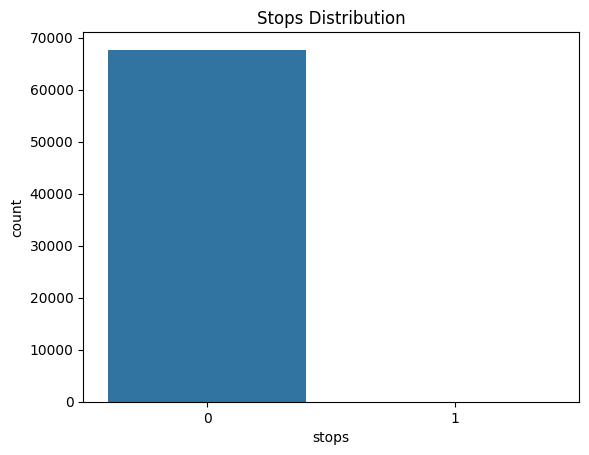

In [27]:
# Stops distribution
sns.countplot(data=df, x='stops')
plt.title("Stops Distribution")
plt.show()

In [28]:
# Total Count of Stops 0:1
df['stops'].value_counts()

stops
0    67652
1       11
Name: count, dtype: int64

In [29]:
# Show 11 routes that have > 0 stops
df[df['stops'] > 0].head(11)

,airline,airline id,source airport,source airport id,destination airport,destination airport id,codeshare,stops,equipment,route
2066,5T,1623,YRT,132,YEK,50,NaN,1,ATR,YRT-YEK
7810,AC,330,ABJ,253,BRU,302,NaN,1,333,ABJ-BRU
8272,AC,330,YVR,156,YBL,30,NaN,1,BEH,YVR-YBL
17767,CU,1936,FCO,1555,HAV,1909,NaN,1,767,FCO-HAV
25116,FL,1316,HOU,3566,SAT,3621,NaN,1,735,HOU-SAT
25220,FL,1316,MCO,3878,HOU,3566,NaN,1,73W,MCO-HOU
25230,FL,1316,MCO,3878,ORF,3611,NaN,1,717,MCO-ORF
49746,SK,4319,ARN,737,GEV,715,NaN,1,ATP,ARN-GEV
63567,WN,4547,BOS,3448,MCO,3878,NaN,1,73W,BOS-MCO
64042,WN,4547,MCO,3878,BOS,3448,NaN,1,73W,MCO-BOS


In [30]:
# Expected Behaviour Model
anomalies = df[df['stops'] > 1]
anomalies.head()

,airline,airline id,source airport,source airport id,destination airport,destination airport id,codeshare,stops,equipment,route


In [31]:
# Anomaly Rate
anomaly_rate = (df['stops'] > 1).mean()*100
print(anomaly_rate)

0.0


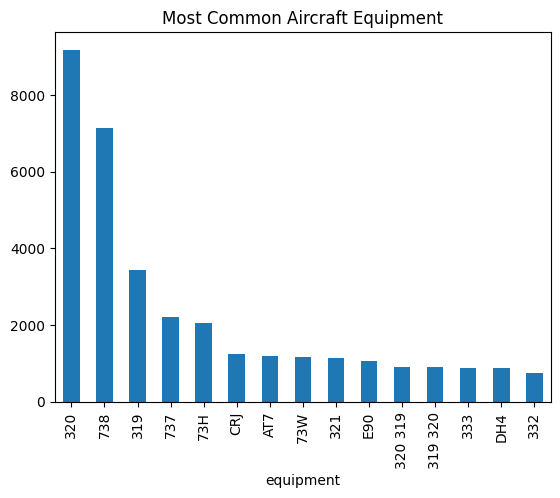

In [32]:
# Common Aircraft Equipment
top_equipment = df['equipment'].value_counts().head(15)

top_equipment.plot(kind='bar')
plt.title("Most Common Aircraft Equipment")
plt.show()

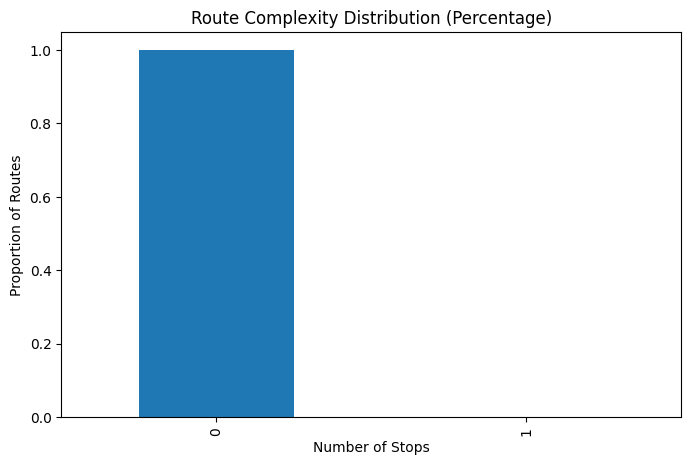

In [33]:
# Stops distribution as percentage
stops_pct = df['stops'].value_counts(normalize=True).sort_index()

plt.figure(figsize=(8,5))
stops_pct.plot(kind='bar')
plt.title("Route Complexity Distribution (Percentage)")
plt.ylabel("Proportion of Routes")
plt.xlabel("Number of Stops")
plt.show()
# The majority of routes are direct, establishing baseline movement behaviour.

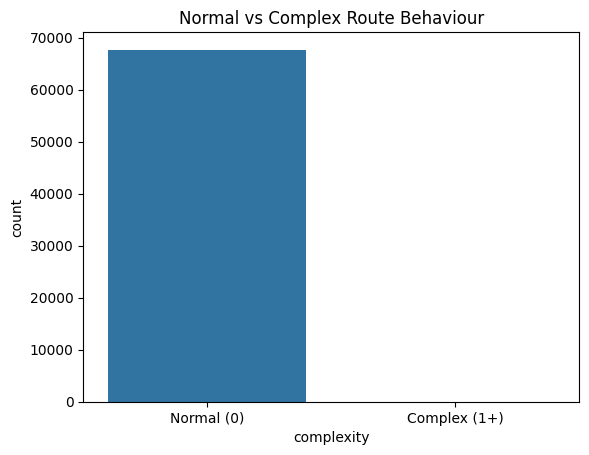

In [34]:
# Highlighting anomalies
df['complexity'] = df['stops'].apply(lambda x: 'Normal (0)' if x==0 else 'Complex (1+)')

sns.countplot(data=df, x='complexity')
plt.title("Normal vs Complex Route Behaviour")
plt.show()
# Routes with additional stops represent a minority and may require specialised modelling approaches.

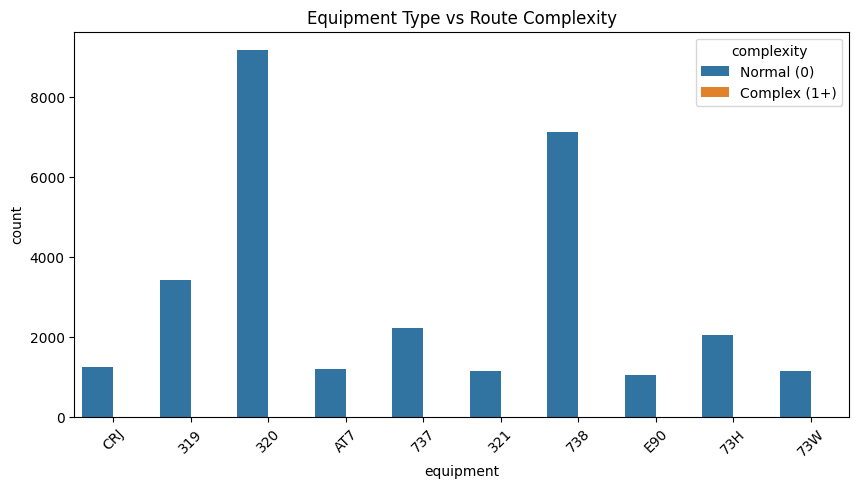

In [35]:
# Equipment vs Complexity
top_eq = df['equipment'].value_counts().head(10).index

subset = df[df['equipment'].isin(top_eq)]

plt.figure(figsize=(10,5))
sns.countplot(data=subset, x='equipment', hue='complexity')
plt.xticks(rotation=45)
plt.title("Equipment Type vs Route Complexity")
plt.show()

#Equipment analysis suggests complexity may vary by aircraft type.

Summary

Baseline Behaviour - 
From exploring the dataset, most routes are direct with zero stops. This suggests that the typical movement pattern is a single journey between two airports without intermediate segments. The distribution of stops is very imbalanced, with direct routes making up the majority of the data.

Anomaly Definition - 
To understand less common behaviour, routes were grouped based on the number of stops. Routes with one or more stops were treated as more complex, and routes with more than one stop were considered rare. This helped highlight routes that differ from the usual pattern.

Key Findings - 
- Direct routes dominate the data set with occassional multi-stop routes.
- Less common routes show movement of patterns can vary and need seperate consideration in analysis.
- Differences observe across aircraft equipment types, suggests route complexity can be influenced by the type of aircraft used.
- Imbalances between common and rare routes show why it is important to look beyong averages and explore unsuual cases.

Limitations - 
- This dataset describes route definitions rather than flight trajectory over time.
- Timing, delays and envrionmnental factors are not included and could impact overall data.
- Equipment information is incomplete/missing for some entries.

Further work could include datsets with time info so movement can be tracked over time rather than just through route definition. Adding distance comparisons and predictive models could also help explore how route complexity changes across different scenarios giving a better picture of real movement behaviour.